# Chapter 11 notebook — Edge LLM intro (concept)

Walks through `docs/18_edge_llm_multimodal_ai.md`:
1. Memory budget math for a few model sizes.
2. Where common edge devices land on those budgets.
3. (Optional) generate text with a small HF model if you want to download weights.

This notebook does NOT download a model by default. The download cells are clearly marked; uncomment to run.

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

def memory_estimate(params_b: float, w_bits: int = 4, layers: int = 32,
                    hidden: int = 4096, seq_len: int = 2048,
                    kv_bits: int = 8, overhead_mb: int = 500) -> dict:
    weights_gb = params_b * 1e9 * (w_bits / 8) / 1024**3
    kv_gb = (layers * seq_len * hidden * 2 * (kv_bits / 8)) / 1024**3
    activations_gb = (4 * hidden * seq_len * 2) / 1024**3   # rough
    total_gb = weights_gb + kv_gb + activations_gb + overhead_mb / 1024
    return {'weights_gb': weights_gb, 'kv_cache_gb': kv_gb,
            'activations_gb': activations_gb,
            'overhead_gb': overhead_mb / 1024,
            'total_gb': total_gb}

configs = [
    ('Qwen-2.5-0.5B INT8', 0.5, 8, 24, 1024, 2048),
    ('Phi-3-mini INT4',    3.8, 4, 32, 3072, 2048),
    ('Gemma-2B INT4',      2.5, 4, 18, 2304, 2048),
    ('Llama-3-8B INT4',    8.0, 4, 32, 4096, 2048),
    ('Llama-3-8B INT8',    8.0, 8, 32, 4096, 2048),
    ('Llama-3-8B FP16',    8.0, 16, 32, 4096, 2048),
]
print(f'{"model":<25s} {"weights":>10s} {"KV":>8s} {"act":>8s} {"total":>10s}')
rows = []
for name, p, wb, L, H, S in configs:
    m = memory_estimate(p, w_bits=wb, layers=L, hidden=H, seq_len=S)
    rows.append((name, m))
    print(f'{name:<25s} {m["weights_gb"]:>8.2f} GB {m["kv_cache_gb"]:>6.2f} GB '
          f'{m["activations_gb"]:>6.2f} GB {m["total_gb"]:>8.2f} GB')

model                        weights       KV      act      total
Qwen-2.5-0.5B INT8            0.47 GB   0.09 GB   0.02 GB     1.06 GB
Phi-3-mini INT4               1.77 GB   0.38 GB   0.05 GB     2.68 GB
Gemma-2B INT4                 1.16 GB   0.16 GB   0.04 GB     1.85 GB
Llama-3-8B INT4               3.73 GB   0.50 GB   0.06 GB     4.78 GB
Llama-3-8B INT8               7.45 GB   0.50 GB   0.06 GB     8.50 GB
Llama-3-8B FP16              14.90 GB   0.50 GB   0.06 GB    15.95 GB


## 2. Which devices can run which model?

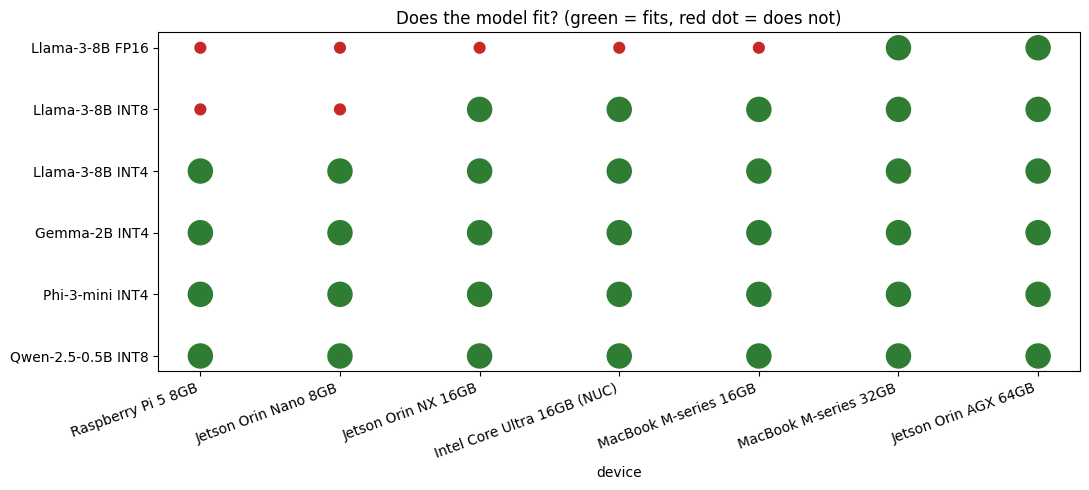

In [2]:
devices = [
    ('Raspberry Pi 5 8GB',                   6),
    ('Jetson Orin Nano 8GB',                 6),
    ('Jetson Orin NX 16GB',                 14),
    ('Intel Core Ultra 16GB (NUC)',         14),
    ('MacBook M-series 16GB',                14),
    ('MacBook M-series 32GB',                30),
    ('Jetson Orin AGX 64GB',                 60),
]
fig, ax = plt.subplots(figsize=(11, 5))
for name, m in rows:
    fits = [(d, m['total_gb'] <= cap_gb) for d, cap_gb in devices]
    xs = [d for d, _ in fits]
    ys = [1 if f else 0 for _, f in fits]
    ax.scatter(xs, [name]*len(xs), s=[300 if f else 60 for f in ys],
               c=['#2e7d32' if f else '#c62828' for f in ys])
ax.set_xlabel('device')
ax.set_title('Does the model fit? (green = fits, red dot = does not)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 3. Decision framework

For your project (or in general):

- **3B INT4**: most laptops, Jetson Orin Nano. Good for camera assistants, on-device transcription, simple Q&A.
- **7-8B INT4**: 16 GB+ laptops, Orin NX, Intel Core Ultra NPU. Good for richer assistants, code, longer reasoning.
- **70B+**: not edge in 2026.

For VLM:
- **Moondream / Florence-2**: small, fast image-to-text. Edge-friendly.
- **Phi-3-Vision**: needs 8GB+; Jetson Orin NX or 16GB laptop.

For VLA (robotics):
- Out of edge scope in 2026 unless on Jetson Orin AGX.

## 4. (OPTIONAL) Run a tiny model locally

Uncomment the cell below to download and run a small instruction-tuned model. Beware: this downloads ~1-3 GB of weights and needs the `transformers` package installed (`pip install transformers accelerate`).

In [3]:
# Uncomment to run:
#
# from transformers import pipeline
# pipe = pipeline('text-generation', model='Qwen/Qwen2.5-0.5B-Instruct',
#                 torch_dtype='auto', device_map='auto')
# prompt = 'You are an edge AI assistant. Explain why on-device inference matters in one sentence.'
# import time
# t0 = time.perf_counter()
# out = pipe(prompt, max_new_tokens=80, do_sample=False)[0]['generated_text']
# elapsed = time.perf_counter() - t0
# print(out)
# # Rough TPS estimate (new tokens only): tokens / elapsed
# n_new = len(out.split()) - len(prompt.split())
# print(f'\n~{n_new / elapsed:.1f} tokens/s')

## Take-aways

1. The single biggest constraint for edge LLM is RAM (weights + KV cache), not compute.
2. INT4 quantization is what makes 7-8B models fit on consumer hardware.
3. Long context = bigger KV cache = more RAM. Reduce `max_seq_len` if you are tight.
4. For most edge AI projects in 2026, cloud LLM is still the right answer. On-device LLM is for **privacy / offline / sub-second latency / cost-at-scale** use cases.
5. VLA (vision-language-action) is the future of the Physical AI decision layer — but in 2026 it is server-class, not edge.